In [1]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
PyTorch version: 2.14.0+cpu
CUDA available: False


In [2]:
df = pd.read_csv(
    "../data/processed/mobile_reviews_text_processed.csv"
)

print("Dataset shape:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset shape: (4200, 34)

Sentiment distribution:
sentiment
Positive    1764
Negative    1386
Neutral     1050
Name: count, dtype: int64


In [3]:
print("Rows before duplicate removal:", len(df))

df = df.drop_duplicates(
    subset=["clean_review"],
    keep="first"
).copy()

print("Rows after duplicate removal:", len(df))

Rows before duplicate removal: 4200
Rows after duplicate removal: 4200


In [4]:
label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

df["label"] = df["sentiment"].map(label2id)

print(df[["sentiment", "label"]].head())

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

  sentiment  label
0  Positive      2
1   Neutral      1
2  Positive      2
3  Negative      0
4  Positive      2

Label distribution:
label
0    1386
1    1050
2    1764
Name: count, dtype: int64


In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining distribution:")
print(train_df["sentiment"].value_counts())

print("\nTesting distribution:")
print(test_df["sentiment"].value_counts())

Training samples: 3360
Testing samples: 840

Training distribution:
sentiment
Positive    1411
Negative    1109
Neutral      840
Name: count, dtype: int64

Testing distribution:
sentiment
Positive    353
Negative    277
Neutral     210
Name: count, dtype: int64


In [6]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("DistilBERT loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded successfully.


In [7]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dynamic padding data collator created.")

Dynamic padding data collator created.


In [8]:
train_dataset = Dataset.from_pandas(
    train_df[["clean_review", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_review", "label"]],
    preserve_index=False
)

print("Training dataset:", train_dataset)
print("Testing dataset:", test_dataset)

Training dataset: Dataset({
    features: ['clean_review', 'label'],
    num_rows: 3360
})
Testing dataset: Dataset({
    features: ['clean_review', 'label'],
    num_rows: 840
})


In [9]:
def tokenize_function(batch):
    return tokenizer(
        batch["clean_review"],
        truncation=True,
        max_length=128
    )


train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")

Map:   0%|          | 0/3360 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

Tokenization completed.


In [10]:
train_tokenized = train_tokenized.remove_columns(
    ["clean_review"]
)

test_tokenized = test_tokenized.remove_columns(
    ["clean_review"]
)

print(train_tokenized)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3360
})


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [12]:
training_args = TrainingArguments(
    output_dir="../models/trained_models/distilbert_sentiment_v2",

    num_train_epochs=2,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=25,

    report_to="none",

    fp16=False,

    dataloader_pin_memory=False
)

print("Training configuration created.")

Training configuration created.


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


In [14]:
print("Starting DistilBERT training...")
print("Training samples:", len(train_tokenized))
print("Epochs:", training_args.num_train_epochs)
print()

train_result = trainer.train()

print("\n===== TRAINING COMPLETED =====")
print(train_result)

Starting DistilBERT training...
Training samples: 3360
Epochs: 2



Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.619593,0.498860,0.802381,0.815640,0.768727,0.775275
2,0.483859,0.508529,0.800000,0.800476,0.768749,0.775640


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== TRAINING COMPLETED =====
TrainOutput(global_step=840, training_loss=0.6045543659301031, metrics={'train_runtime': 656.8123, 'train_samples_per_second': 10.231, 'train_steps_per_second': 1.279, 'total_flos': 113046382313856.0, 'train_loss': 0.6045543659301031, 'epoch': 2.0})


In [15]:
# Generate predictions on the test set

pred_output = trainer.predict(test_tokenized)

pred_logits = pred_output.predictions
true_labels = test_df["label"].values

pred_labels = np.argmax(pred_logits, axis=-1)

print("Predictions generated.")
print("Number of test samples:", len(pred_labels))

Predictions generated.
Number of test samples: 840


In [16]:
# Convert numeric labels back to sentiment names

pred_sentiments = [
    id2label[int(label)]
    for label in pred_labels
]

true_sentiments = [
    id2label[int(label)]
    for label in true_labels
]

print("===== DISTILBERT CLASSIFICATION REPORT =====")

print(
    classification_report(
        true_sentiments,
        pred_sentiments,
        labels=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

===== DISTILBERT CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative     0.8423    0.8484    0.8453       277
     Neutral     0.7808    0.5429    0.6404       210
    Positive     0.7783    0.9150    0.8411       353

    accuracy                         0.8000       840
   macro avg     0.8005    0.7687    0.7756       840
weighted avg     0.8000    0.8000    0.7923       840



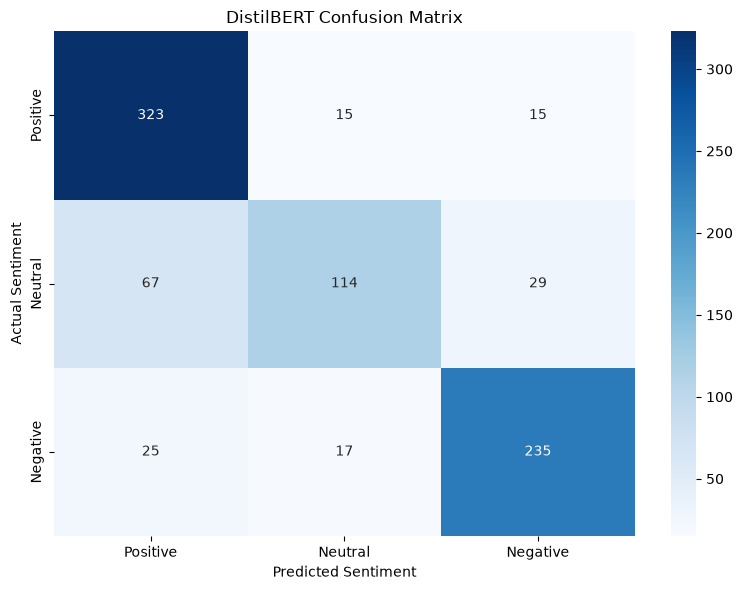

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

labels_order = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    true_sentiments,
    pred_sentiments,
    labels=labels_order
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        0.7333,
        0.792857
    ],
    "Macro F1": [
        0.7124,
        0.770687
    ]
})

comparison

,Model,Accuracy,Macro F1
0,TF-IDF + Logistic Regression,0.733300,0.712400
1,DistilBERT,0.792857,0.770687


In [19]:
# Save the final DistilBERT model and tokenizer

MODEL_SAVE_PATH = "../models/trained_models/distilbert_sentiment_v2"

trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print("DistilBERT model saved successfully.")
print("Saved to:", MODEL_SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved successfully.
Saved to: ../models/trained_models/distilbert_sentiment_v2
